# Organoid skeleton construction: step-by-step walkthrough

This notebook walks through building a **biology-aware skeleton graph** for a small batch of intestinal organoids. It follows the same spirit as `tutorial_segmentation.ipynb`: keep intermediate objects visible, make the important parameters easy to edit, and provide quick visual feedback.

The skeleton is not a generic medial axis. It is built from fresh crypt detections and uses straight graph edges only:

- `body -> neck -> tip` for a simple crypt;
- `body -> neck -> bend -> tip` when a bend node is requested;
- `body -> neck -> branch -> daughter neck -> daughter tip` when an initial crypt candidate splits into multiple refined crypts.

The most useful tuning loop is the batch run: change the crypt detection, filtering, refinement, and bend-node parameters, rebuild the skeletons, and inspect each mesh overlay plus node/edge tables.

In [22]:
# --- Imports ---
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, display

from organograph.io_utils.dataset_config import load_mesh_dataset_config
from organograph.io_utils.path_parsing import discover_mesh_paths, parse_mesh_path
from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.mesh.geodesics import compute_geodesics_dijkstra

from organograph.crypts.filters import filter_crypts_by_hks_percent, filter_crypts_by_size

# During skeleton development, Jupyter may keep an older version of these modules
# in memory. Drop only the skeleton modules so imports below reflect the files on disk.
import importlib
import sys

for _mod in [
    "organograph.skeleton.build",
    "organograph.skeleton.datatypes",
    "organograph.skeleton.geometry",
    "organograph.skeleton.io",
    "organograph.skeleton.primitives",
    "organograph.skeleton",
]:
    sys.modules.pop(_mod, None)
importlib.invalidate_caches()
from organograph.plotting.skeletons import plot_mesh_with_skeleton

from organograph.skeleton.build import (
    build_skeleton_from_crypt_detections,
    detect_crypts_for_skeleton,
)
from organograph.skeleton.geometry import (
    crypt_attachment_direction,
    crypt_bend_angle,
    crypt_path_length,
    crypt_straight_distance,
    crypt_tortuosity,
    number_of_crypts,
    number_of_split_crypts,
)


pd.set_option("display.max_colwidth", 120)

## 1) Dataset paths + organoid selection

Edit this cell first. The tutorial now runs a batch of organoids. Each entry only needs a `timepoint`, `well`, and `organoid_id`; the notebook reads `mesh_config.json` to fill in the zarr, round, and mesh folder names.


In [23]:
# -----------------------
# CONFIG: edit these
# -----------------------

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "notebooks" and (NOTEBOOK_DIR / "notebooks").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATASET = "20251201"

MESH_DATA_DIR = PROJECT_ROOT.parent / "NicoleData" / DATASET / "fractal_output"
MESH_CONFIG_PATH = PROJECT_ROOT.parent / "NicoleData" / DATASET / "mesh_config.json"
VOCAB_PATH = PROJECT_ROOT / "sim" / "vocab_with_meta.npz"

# Organoids copied from tutorial_segmentation.ipynb.
ORGANOID_SPECS = [
    {"timepoint": "day4p5", "well": "B03", "organoid_id": "144"},
    {"timepoint": "day4p5", "well": "B02", "organoid_id": "124"},
    {"timepoint": "day4p5", "well": "B04", "organoid_id": "4"},
    {"timepoint": "day4p5", "well": "B05", "organoid_id": "54"},
    {"timepoint": "day4p5", "well": "B02", "organoid_id": "115"},
    {"timepoint": "day4p5", "well": "B02", "organoid_id": "100"},
    {"timepoint": "day4p5", "well": "B02", "organoid_id": "31"},
]

# Optional escape hatch for unusual paths: {"well/organoid_id": "/full/path/file.vtp"}
MESH_PATH_OVERRIDES = {}

print("PROJECT_ROOT     =", PROJECT_ROOT)
print("MESH_DATA_DIR   =", MESH_DATA_DIR)
print("MESH_CONFIG_PATH=", MESH_CONFIG_PATH)
print("VOCAB_PATH      =", VOCAB_PATH)
print("n_organoids     =", len(ORGANOID_SPECS))


PROJECT_ROOT     = /home/fmoller/Projects/LearningOrganoids/OrganoGraph
MESH_DATA_DIR   = /home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output
MESH_CONFIG_PATH= /home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/mesh_config.json
VOCAB_PATH      = /home/fmoller/Projects/LearningOrganoids/OrganoGraph/sim/vocab_with_meta.npz
n_organoids     = 7


In [24]:
# --- Build mesh paths from dataset/timepoint/well/organoid ids ---
mesh_cfg = load_mesh_dataset_config(str(MESH_CONFIG_PATH))


def mesh_path_from_spec(spec):
    timepoint = str(spec["timepoint"])
    well = str(spec["well"])
    organoid_id = str(spec["organoid_id"])
    override_key = f"{well}/{organoid_id}"
    if override_key in MESH_PATH_OVERRIDES:
        return Path(MESH_PATH_OVERRIDES[override_key])

    if timepoint not in mesh_cfg["zarr_name_by_tp"]:
        raise KeyError(f"timepoint={timepoint!r} is not present in {MESH_CONFIG_PATH}")
    if len(well) < 2:
        raise ValueError(f"well should look like 'B03', got {well!r}")

    return (
        Path(MESH_DATA_DIR)
        / timepoint
        / mesh_cfg["zarr_name_by_tp"][timepoint]
        / well[0]
        / well[1:]
        / mesh_cfg["round_by_tp"][timepoint]
        / "meshes"
        / mesh_cfg["meshname_by_tp"][timepoint]
        / f"{organoid_id}.vtp"
    )


organoid_records = []
missing = []
for spec in ORGANOID_SPECS:
    mesh_path = mesh_path_from_spec(spec)
    rec = dict(spec)
    rec["mesh_path"] = str(mesh_path)
    rec["label_uid"] = f"{rec['timepoint']}_{rec['well']}_{rec['organoid_id']}"
    if mesh_path.exists():
        try:
            parsed = parse_mesh_path(str(mesh_path))
            rec["label_uid"] = parsed.get("label_uid", rec["label_uid"])
        except Exception:
            pass
        organoid_records.append(rec)
    else:
        missing.append(rec)

if missing:
    print("Missing requested mesh paths:")
    for rec in missing:
        print(" ", rec["mesh_path"])
        nearby = discover_mesh_paths(
            data_dir=str(MESH_DATA_DIR),
            timepoints=[rec["timepoint"]],
            zarr_names=mesh_cfg["zarr_name_by_tp"],
            rounds=mesh_cfg["round_by_tp"],
            meshes=mesh_cfg["meshname_by_tp"],
            wells={rec["timepoint"]: [rec["well"]]},
        )
        print(f"   available IDs in {rec['timepoint']}/{rec['well']}:", [Path(p).stem for p in nearby[:20]])
    raise FileNotFoundError("One or more requested organoids were not found.")

organoid_table = pd.DataFrame(organoid_records)
display(organoid_table)


,timepoint,well,organoid_id,mesh_path,label_uid
0,day4p5,B03,144,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/03/2_zillum_regis...,day4p5_B03_144
1,day4p5,B02,124,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/02/2_zillum_regis...,day4p5_B02_124
2,day4p5,B04,4,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/04/2_zillum_regis...,day4p5_B04_4
3,day4p5,B05,54,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/05/2_zillum_regis...,day4p5_B05_54
4,day4p5,B02,115,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/02/2_zillum_regis...,day4p5_B02_115
5,day4p5,B02,100,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/02/2_zillum_regis...,day4p5_B02_100
6,day4p5,B02,31,/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/02/2_zillum_regis...,day4p5_B02_31


## 2) Load and prepare meshes

The HKS-based crypt detector needs a Laplace-Beltrami eigendecomposition for each mesh. Meshes are loaded lazily and cached as the batch loop runs. If smoothing is enabled here, the low-pass reconstructed mesh is used for detection, skeleton construction, and plotting.


In [25]:
NORMALIZE_MESH = True
NORMALIZE_SCALE = 10.0
EIGEN_K = 225

# --- Optional mesh smoothing before any detection/skeleton/plotting step ---
# If enabled, the mesh vertices are replaced by a low-pass spectral reconstruction.
SMOOTH_MESH = True
SMOOTH_LMAX = 12
SMOOTH_EIGEN_K = None  # None uses EIGEN_K after smoothing.

vocab = np.load(str(VOCAB_PATH), allow_pickle=True)
MESH_CACHE = {}


def _clamped_eigen_k(mesh, requested_k):
    n_vertices = int(np.asarray(mesh.v).shape[0])
    return max(2, min(int(requested_k), n_vertices - 2))


def _reset_spectral_state(mesh):
    mesh.laplacian = None
    mesh.mass_matrix = None
    mesh.eigvals = None
    mesh.eigvecs = None
    mesh.coeffs_v = None
    mesh.lmax = None


def _ensure_mesh_eigendecomposition(mesh, requested_k):
    k = _clamped_eigen_k(mesh, requested_k)
    if mesh.eigvals is None or mesh.eigvecs is None or mesh.eigvecs.shape[1] < k:
        _reset_spectral_state(mesh)
        mesh._eig_decomp(k=k)
    return k


def _smooth_mesh_low_pass(mesh):
    lmax = int(SMOOTH_LMAX)
    if lmax < 1:
        raise ValueError("SMOOTH_LMAX must be at least 1")

    coeff_k = int(lmax ** 2)
    _ensure_mesh_eigendecomposition(mesh, max(EIGEN_K, coeff_k))
    mesh.compute_spectral_coefficients(lmax=lmax)
    mesh.v = np.asarray(mesh.reconstruct_from_coeffs(mesh.coeffs_v, lmax=lmax), dtype=float)

    # The spectral operators must match the smoothed coordinates used downstream.
    _reset_spectral_state(mesh)
    _ensure_mesh_eigendecomposition(mesh, SMOOTH_EIGEN_K or EIGEN_K)
    return mesh


def load_prepared_mesh(record):
    label_uid = record["label_uid"]
    if label_uid in MESH_CACHE:
        return MESH_CACHE[label_uid]

    mesh = OrganoidMesh(str(record["mesh_path"]))
    mesh.label_uid = label_uid

    if NORMALIZE_MESH:
        mesh.normalize_inplace(scale=NORMALIZE_SCALE, center="mean")

    if SMOOTH_MESH:
        _smooth_mesh_low_pass(mesh)
    else:
        # This also builds the mass matrix used by vertex_areas().
        _ensure_mesh_eigendecomposition(mesh, EIGEN_K)
    MESH_CACHE[label_uid] = mesh
    return mesh


print("vocab entries:", np.asarray(vocab["vocab"]).shape)
print("batch size   :", len(organoid_records))


vocab entries: (8, 20)
batch size   : 7


## 3) Tuning parameters

The skeleton adapter intentionally reruns detection from the fresh HKS candidate screen. This is useful for split crypts: the initial candidate patch can serve as the skeleton trunk/stem, while refinement identifies daughter tips.

Mesh smoothing is controlled in the preparation cell above so the same vertices are used everywhere. `DETECTION_KWARGS` controls HKS candidate detection, boundary-distance neckline normalization, post-neck HKS-guided skeleton-tip refinement with an optional minimum HKS-increase threshold, and split-stem validation by parent-patch boundary growth, including optional pre-growth perimeter smoothing and an absolute mesh-fraction growth cap. `FILTER_KWARGS` controls reusable crypt filters. `BUILD_KWARGS` controls graph construction, especially optional bend-node insertion and region-centroid refinement of body/branch nodes.

`bend_strategy="none"` builds direct neck-to-tip edges. Use `bend_strategy="crypt_centroid"` to insert a `crypt` node at the centroid of the detected crypt vertices, or `midpoint` / `crypt_centroid_midsection` to insert a `bend` node.


In [26]:
# --- Crypt detection parameters ---
DETECTION_KWARGS = dict(
    L_ref=None,
    crypt_vocab_idx=None,
    threshold=0.5,
    refine_crypts=True,
    refine_threshold=0.00,
    refine_only_if_area_at_least=5.0,
    min_refined_frac_of_parent=0.05,
    geodesic_kwargs=None,
    final_tip_hks_time=1.0,
    final_tip_bottom_fraction=0.8,
    final_tip_min_hks_percent_increase=5.0,  # require updated-tip HKS to exceed initial-tip HKS by this percent
    extend_max=2.0,
    disc_resolution=200,
    neck_search_interval=(0.8, 2.0),
    # Branch refinement: keep split hierarchy only if parent-patch growth
    # finds a robust global boundary-length minimum.
    validate_split_stems=True,
    split_growth_max_size_factor=3.0,
    split_growth_max_mesh_fraction=0.40,
    split_growth_smooth_perimeter=True,
    split_growth_smoothing_tolerance=0.0,
    split_growth_min_decrease_fraction=0.0,
    split_growth_min_prominence_fraction=0.01,
    split_growth_robust_window=1,
)

# --- Candidate filters ---
FILTER_KWARGS = dict(
    use_hks_filter=True,
    min_percent_greater=2.0,
    hks_t_min=None,
    hks_t_max=10.0,
    use_size_filter=True,
    min_patch_verts=25,
    min_patch_area=5.0,
)

# --- Skeleton graph parameters ---
BUILD_KWARGS = dict(
    body_center=None,
    # "none" gives direct neck-to-tip edges; "crypt_centroid" inserts the central crypt node.
    bend_strategy="crypt_centroid",  # "none", "crypt_centroid", "midpoint", "crypt_centroid_midsection"
    refine_body_center_from_necks=True,
    refine_branch_centers_from_necks=True,
)

def make_filter_list(**kw):
    filters = []
    if kw.get("use_hks_filter", True):
        filters.append(
            lambda patches, **inner: filter_crypts_by_hks_percent(
                patches,
                min_percent_greater=kw["min_percent_greater"],
                t_min=kw.get("hks_t_min"),
                t_max=kw.get("hks_t_max"),
                **inner,
            )
        )
    if kw.get("use_size_filter", True):
        filters.append(
            lambda patches, **inner: filter_crypts_by_size(
                patches,
                min_patch_verts=kw["min_patch_verts"],
                min_patch_area=kw.get("min_patch_area"),
                **inner,
            )
        )
    return filters or None

## 4) Build skeletons for the batch

The function below is the main tuning loop. It runs detection and skeleton construction for every organoid in `organoid_records`, then displays each skeleton figure before its tables.

Skeleton crypts: 3
Split crypts   : 1
Nodes / edges  : 15 / 14


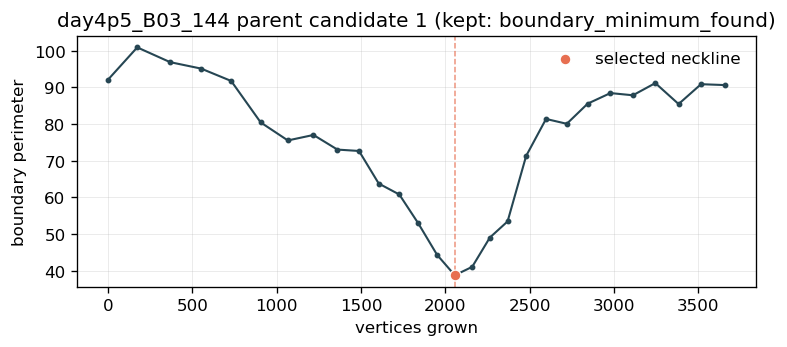

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,11.596720,8.651376,1.340448,0.0,0.496268,-0.815892,-0.296712
1,1,12.139201,8.528510,1.423367,0.0,-0.282654,0.959218,-0.002630
2,2,5.585746,5.583182,1.000459,0.0,-0.325829,-0.906558,0.268306


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,-0.897422,0.560621,0.070042,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,3.014195,-5.870302,-2.268659,"{'source_detection_index': 0, 'n_crypt_vertices': 3443, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_tip,tip,0.0,10.780439,-9.022524,-0.125005,"{'source_detection_index': 0, 'n_crypt_vertices': 3443, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_crypt,crypt,0.0,6.879490,-11.351091,-0.084256,"{'source_detection_index': 0, 'n_crypt_vertices': 3443, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_1_neck,neck,1.0,-2.879372,7.286601,0.051602,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_1_branch,branch,1.0,-2.679199,11.041149,-0.568220,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_1_daughter_0_neck,neck,1.0,-6.659438,9.223428,-0.630549,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_1_tip_0,tip,1.0,-9.190143,7.727084,-0.765640,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_1_daughter_0_crypt,crypt,1.0,-8.606745,7.821470,-0.606699,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_1_daughter_1_neck,neck,1.0,1.640568,10.607325,-0.019139,"{'source_detection_index': 1, 'n_crypt_vertices': 3307, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_crypt,crypt_0_neck,crypt_0_crypt,neck_to_crypt,0,{},None
2,crypt_0_crypt_to_tip,crypt_0_crypt,crypt_0_tip,crypt_to_tip,0,{},None
3,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
4,crypt_1_neck_to_branch,crypt_1_neck,crypt_1_branch,neck_to_branch,1,{},None
5,crypt_1_branch_to_daughter_0_neck,crypt_1_branch,crypt_1_daughter_0_neck,branch_to_neck,1,{},None
6,crypt_1_daughter_0_neck_to_crypt,crypt_1_daughter_0_neck,crypt_1_daughter_0_crypt,neck_to_crypt,1,{},None
7,crypt_1_daughter_0_crypt_to_tip,crypt_1_daughter_0_crypt,crypt_1_tip_0,crypt_to_tip,1,{},None
8,crypt_1_branch_to_daughter_1_neck,crypt_1_branch,crypt_1_daughter_1_neck,branch_to_neck,1,{},None
9,crypt_1_daughter_1_neck_to_crypt,crypt_1_daughter_1_neck,crypt_1_daughter_1_crypt,neck_to_crypt,1,{},None


Skeleton crypts: 2
Split crypts   : 1
Nodes / edges  : 12 / 11


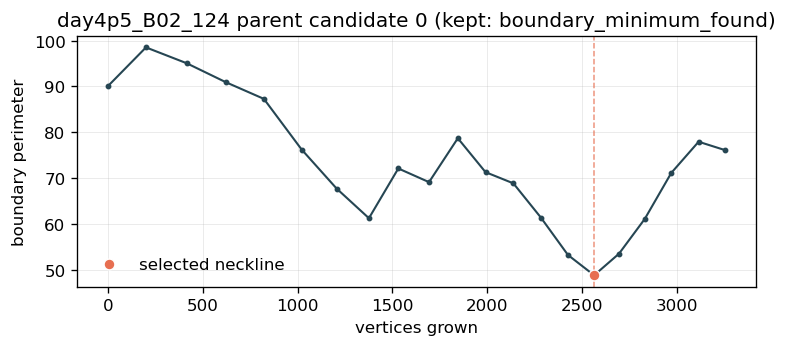

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,10.434647,8.03871,1.298050,0.0,-0.442057,-0.878004,-0.183560
1,1,9.256287,9.23617,1.002178,0.0,-0.234161,0.965923,-0.110278


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,1.888743,0.708070,0.532745,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,-1.064511,-5.157628,-0.693566,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_branch,branch,0.0,-0.928942,-8.386850,-1.218201,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_daughter_0_neck,neck,0.0,1.942227,-8.600682,0.170025,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_0_tip_0,tip,0.0,5.283449,-8.053492,0.958706,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_0_daughter_0_crypt,crypt,0.0,4.443480,-8.226864,0.703857,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_0_daughter_1_neck,neck,0.0,-2.857787,-9.180652,0.842270,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_0_tip_1,tip,0.0,-6.055870,-9.847136,3.515439,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_0_daughter_1_crypt,crypt,0.0,-5.363087,-9.598298,2.932843,"{'source_detection_index': 0, 'n_crypt_vertices': 3811, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_1_neck,neck,1.0,0.276578,7.358310,-0.226505,"{'source_detection_index': 1, 'n_crypt_vertices': 3513, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_branch,crypt_0_neck,crypt_0_branch,neck_to_branch,0,{},None
2,crypt_0_branch_to_daughter_0_neck,crypt_0_branch,crypt_0_daughter_0_neck,branch_to_neck,0,{},None
3,crypt_0_daughter_0_neck_to_crypt,crypt_0_daughter_0_neck,crypt_0_daughter_0_crypt,neck_to_crypt,0,{},None
4,crypt_0_daughter_0_crypt_to_tip,crypt_0_daughter_0_crypt,crypt_0_tip_0,crypt_to_tip,0,{},None
5,crypt_0_branch_to_daughter_1_neck,crypt_0_branch,crypt_0_daughter_1_neck,branch_to_neck,0,{},None
6,crypt_0_daughter_1_neck_to_crypt,crypt_0_daughter_1_neck,crypt_0_daughter_1_crypt,neck_to_crypt,0,{},None
7,crypt_0_daughter_1_crypt_to_tip,crypt_0_daughter_1_crypt,crypt_0_tip_1,crypt_to_tip,0,{},None
8,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
9,crypt_1_neck_to_crypt,crypt_1_neck,crypt_1_crypt,neck_to_crypt,1,{},None


Skeleton crypts: 3
Split crypts   : 1
Nodes / edges  : 15 / 14


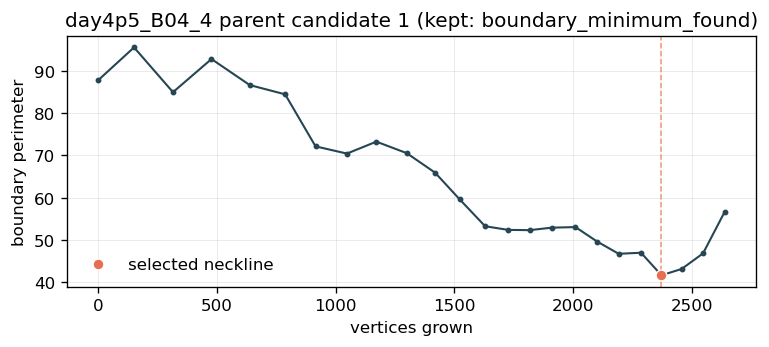

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,3.916148,3.864797,1.013287,0.0,-0.093907,-0.801266,-0.590893
1,1,15.240567,12.627689,1.206917,0.0,-0.070915,0.707504,-0.703143
2,2,8.325273,8.311978,1.001599,0.0,0.803538,-0.442426,-0.398228


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,-2.256623,-2.659360,1.287884,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,-2.842434,-7.657794,-2.398206,"{'source_detection_index': 0, 'n_crypt_vertices': 754, 'detection_stage': 'fresh_initial_candidate', 'split_validati...",None
2,crypt_0_tip,tip,0.0,-4.893856,-10.787845,-3.363142,"{'source_detection_index': 0, 'n_crypt_vertices': 754, 'detection_stage': 'fresh_initial_candidate', 'split_validati...",None
3,crypt_0_crypt,crypt,0.0,-4.520185,-9.783621,-2.926926,"{'source_detection_index': 0, 'n_crypt_vertices': 754, 'detection_stage': 'fresh_initial_candidate', 'split_validati...",None
4,crypt_1_neck,neck,1.0,-2.667029,1.435194,-2.781434,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_1_branch,branch,1.0,-1.634591,6.323082,-0.976831,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_1_daughter_0_neck,neck,1.0,1.131290,8.090078,-0.736393,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_1_tip_0,tip,1.0,7.553171,8.828473,-2.193665,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_1_daughter_0_crypt,crypt,1.0,5.991405,8.533148,-1.961097,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_1_daughter_1_neck,neck,1.0,-3.816019,8.733025,-0.695983,"{'source_detection_index': 1, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_crypt,crypt_0_neck,crypt_0_crypt,neck_to_crypt,0,{},None
2,crypt_0_crypt_to_tip,crypt_0_crypt,crypt_0_tip,crypt_to_tip,0,{},None
3,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
4,crypt_1_neck_to_branch,crypt_1_neck,crypt_1_branch,neck_to_branch,1,{},None
5,crypt_1_branch_to_daughter_0_neck,crypt_1_branch,crypt_1_daughter_0_neck,branch_to_neck,1,{},None
6,crypt_1_daughter_0_neck_to_crypt,crypt_1_daughter_0_neck,crypt_1_daughter_0_crypt,neck_to_crypt,1,{},None
7,crypt_1_daughter_0_crypt_to_tip,crypt_1_daughter_0_crypt,crypt_1_tip_0,crypt_to_tip,1,{},None
8,crypt_1_branch_to_daughter_1_neck,crypt_1_branch,crypt_1_daughter_1_neck,branch_to_neck,1,{},None
9,crypt_1_daughter_1_neck_to_crypt,crypt_1_daughter_1_neck,crypt_1_daughter_1_crypt,neck_to_crypt,1,{},None


Skeleton crypts: 2
Split crypts   : 1
Nodes / edges  : 12 / 11


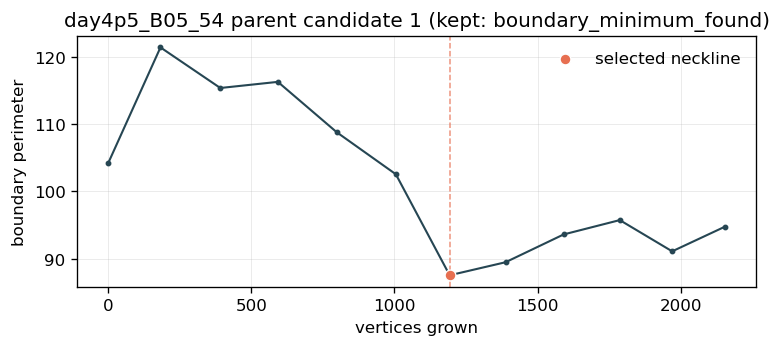

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,13.065168,8.562218,1.525909,0.0,-0.408528,-0.912110,0.034050
1,1,14.351468,9.407119,1.525597,0.0,0.879954,0.459051,0.122283


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,-1.076602,1.729846,-0.516602,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,-3.176197,-2.957869,-0.341603,"{'source_detection_index': 0, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_tip,tip,0.0,3.953797,-7.377452,1.373638,"{'source_detection_index': 0, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_crypt,crypt,0.0,-2.014756,-9.457992,0.103660,"{'source_detection_index': 0, 'n_crypt_vertices': 4448, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_1_neck,neck,1.0,3.039855,3.877304,0.055441,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_1_branch,branch,1.0,6.065622,4.654893,1.085299,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_1_daughter_0_neck,neck,1.0,6.258061,7.658959,-1.693811,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_1_tip_0,tip,1.0,8.108725,8.951859,-3.013016,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_1_daughter_0_crypt,crypt,1.0,7.855175,8.600585,-2.751817,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_1_daughter_1_neck,neck,1.0,1.494642,8.116308,0.553834,"{'source_detection_index': 1, 'n_crypt_vertices': 4891, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_crypt,crypt_0_neck,crypt_0_crypt,neck_to_crypt,0,{},None
2,crypt_0_crypt_to_tip,crypt_0_crypt,crypt_0_tip,crypt_to_tip,0,{},None
3,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
4,crypt_1_neck_to_branch,crypt_1_neck,crypt_1_branch,neck_to_branch,1,{},None
5,crypt_1_branch_to_daughter_0_neck,crypt_1_branch,crypt_1_daughter_0_neck,branch_to_neck,1,{},None
6,crypt_1_daughter_0_neck_to_crypt,crypt_1_daughter_0_neck,crypt_1_daughter_0_crypt,neck_to_crypt,1,{},None
7,crypt_1_daughter_0_crypt_to_tip,crypt_1_daughter_0_crypt,crypt_1_tip_0,crypt_to_tip,1,{},None
8,crypt_1_branch_to_daughter_1_neck,crypt_1_branch,crypt_1_daughter_1_neck,branch_to_neck,1,{},None
9,crypt_1_daughter_1_neck_to_crypt,crypt_1_daughter_1_neck,crypt_1_daughter_1_crypt,neck_to_crypt,1,{},None


Skeleton crypts: 3
Split crypts   : 0
Nodes / edges  : 10 / 9


,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,6.285148,6.268396,1.002672,0.0,0.094189,-0.946948,-0.307276
1,1,2.939340,2.930093,1.003156,0.0,0.915993,0.172764,-0.362090
2,2,5.349599,5.330566,1.003570,0.0,-0.633688,0.591534,0.498525


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,0.519452,1.449693,-0.027659,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,1.155584,-4.945810,-2.102941,"{'source_detection_index': 0, 'n_crypt_vertices': 3171, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_tip,tip,0.0,0.943872,-11.210168,-2.026907,"{'source_detection_index': 0, 'n_crypt_vertices': 3171, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_crypt,crypt,0.0,0.858285,-8.805255,-1.908084,"{'source_detection_index': 0, 'n_crypt_vertices': 3171, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_1_neck,neck,1.0,4.223797,2.148363,-1.491976,"{'source_detection_index': 1, 'n_crypt_vertices': 1250, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_1_tip,tip,1.0,6.591222,2.854201,-3.067581,"{'source_detection_index': 1, 'n_crypt_vertices': 1250, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_1_crypt,crypt,1.0,5.757985,2.655405,-2.638604,"{'source_detection_index': 1, 'n_crypt_vertices': 1250, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_2_neck,neck,2.0,-2.474711,4.244679,2.327863,"{'source_detection_index': 2, 'n_crypt_vertices': 2385, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_2_tip,tip,2.0,-7.346840,4.468306,4.478976,"{'source_detection_index': 2, 'n_crypt_vertices': 2385, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_2_crypt,crypt,2.0,-5.867691,4.206393,3.736553,"{'source_detection_index': 2, 'n_crypt_vertices': 2385, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_crypt,crypt_0_neck,crypt_0_crypt,neck_to_crypt,0,{},None
2,crypt_0_crypt_to_tip,crypt_0_crypt,crypt_0_tip,crypt_to_tip,0,{},None
3,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
4,crypt_1_neck_to_crypt,crypt_1_neck,crypt_1_crypt,neck_to_crypt,1,{},None
5,crypt_1_crypt_to_tip,crypt_1_crypt,crypt_1_tip,crypt_to_tip,1,{},None
6,crypt_2_body_to_neck,body,crypt_2_neck,body_to_neck,2,{},None
7,crypt_2_neck_to_crypt,crypt_2_neck,crypt_2_crypt,neck_to_crypt,2,{},None
8,crypt_2_crypt_to_tip,crypt_2_crypt,crypt_2_tip,crypt_to_tip,2,{},None


Skeleton crypts: 2
Split crypts   : 1
Nodes / edges  : 12 / 11


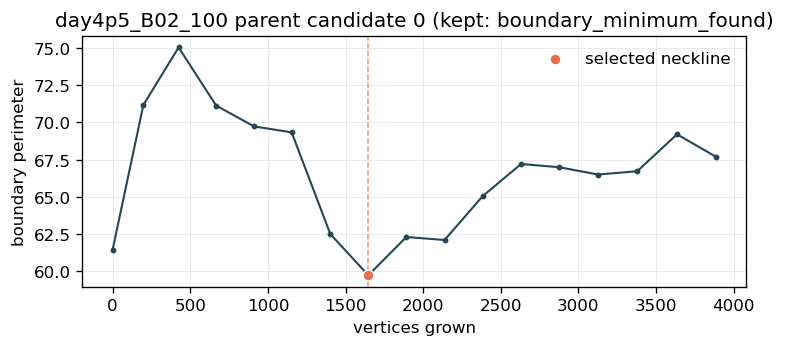

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,5.265719,3.20420,1.643380,0.0,-0.871125,-0.174545,-0.458993
1,1,2.272162,2.26591,1.002759,0.0,0.636970,-0.747392,0.188877


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,NaN,0.554319,0.759257,0.318021,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0.0,-1.952200,0.257033,-1.002656,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_branch,branch,0.0,-3.027965,0.919588,-0.780219,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_daughter_0_neck,neck,0.0,-2.799991,-0.581221,-1.692201,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_0_tip_0,tip,0.0,-4.115321,-1.629477,-2.427045,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
5,crypt_0_daughter_0_crypt,crypt,0.0,-3.915707,-1.662688,-1.805114,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
6,crypt_0_daughter_1_neck,neck,0.0,-4.418034,1.614278,-0.335414,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
7,crypt_0_tip_1,tip,0.0,-4.789902,1.719254,-0.301001,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
8,crypt_0_daughter_1_crypt,crypt,0.0,-4.720790,1.731566,-0.375808,"{'source_detection_index': 0, 'n_crypt_vertices': 3098, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
9,crypt_1_neck,neck,1.0,2.443441,-1.457354,0.878193,"{'source_detection_index': 1, 'n_crypt_vertices': 2640, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_branch,crypt_0_neck,crypt_0_branch,neck_to_branch,0,{},None
2,crypt_0_branch_to_daughter_0_neck,crypt_0_branch,crypt_0_daughter_0_neck,branch_to_neck,0,{},None
3,crypt_0_daughter_0_neck_to_crypt,crypt_0_daughter_0_neck,crypt_0_daughter_0_crypt,neck_to_crypt,0,{},None
4,crypt_0_daughter_0_crypt_to_tip,crypt_0_daughter_0_crypt,crypt_0_tip_0,crypt_to_tip,0,{},None
5,crypt_0_branch_to_daughter_1_neck,crypt_0_branch,crypt_0_daughter_1_neck,branch_to_neck,0,{},None
6,crypt_0_daughter_1_neck_to_crypt,crypt_0_daughter_1_neck,crypt_0_daughter_1_crypt,neck_to_crypt,0,{},None
7,crypt_0_daughter_1_crypt_to_tip,crypt_0_daughter_1_crypt,crypt_0_tip_1,crypt_to_tip,0,{},None
8,crypt_1_body_to_neck,body,crypt_1_neck,body_to_neck,1,{},None
9,crypt_1_neck_to_crypt,crypt_1_neck,crypt_1_crypt,neck_to_crypt,1,{},None


Skeleton crypts: 4
Split crypts   : 0
Nodes / edges  : 13 / 12


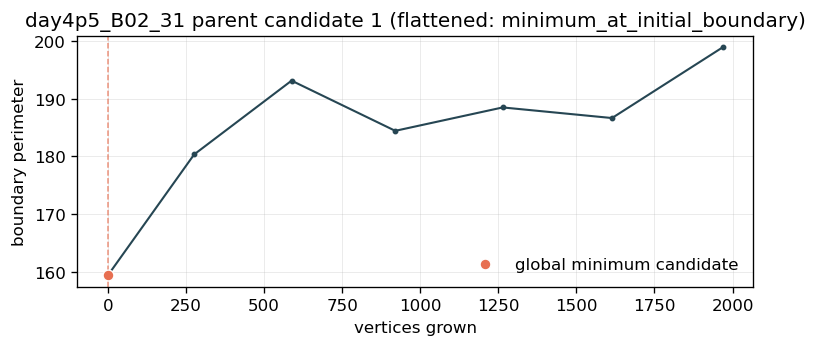

,crypt_id,path_length,straight_distance,tortuosity,bend_angle_rad,attachment_x,attachment_y,attachment_z
0,0,6.461546,5.918513,1.091752,0.0,0.916929,-0.389879,-0.085063
1,1.0,2.004546,1.143643,1.752773,0.0,0.130302,0.930446,-0.342480
2,1.1,6.224726,5.709054,1.090325,0.0,-0.879254,-0.463892,0.108238
3,1.2,1.103821,1.071228,1.030426,0.0,-0.224545,0.945296,0.236633


,node_id,node_type,crypt_id,x,y,z,metadata,primitive_type
0,body,body,None,-1.613184,0.614902,0.066435,"{'role': 'villus_body_center', 'center_refined_from_neck_regions': True}",None
1,crypt_0_neck,neck,0,3.402468,-1.517760,-0.398866,"{'source_detection_index': 0, 'n_crypt_vertices': 3893, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
2,crypt_0_tip,tip,0,9.035086,-3.107795,0.481022,"{'source_detection_index': 0, 'n_crypt_vertices': 3893, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
3,crypt_0_crypt,crypt,0,6.454637,-3.534425,-0.522075,"{'source_detection_index': 0, 'n_crypt_vertices': 3893, 'detection_stage': 'fresh_initial_candidate', 'split_validat...",None
4,crypt_1.0_neck,neck,1.0,-0.629066,7.642180,-2.520177,"{'source_detection_index': 1, 'n_crypt_vertices': 341, 'boundary_distance_bottom_selection': {'strategy': 'boundary_...",None
5,crypt_1.0_tip,tip,1.0,-0.594097,8.471576,-3.306814,"{'source_detection_index': 1, 'n_crypt_vertices': 341, 'boundary_distance_bottom_selection': {'strategy': 'boundary_...",None
6,crypt_1.0_crypt,crypt,1.0,0.007329,8.494141,-2.585909,"{'source_detection_index': 1, 'n_crypt_vertices': 341, 'boundary_distance_bottom_selection': {'strategy': 'boundary_...",None
7,crypt_1.1_neck,neck,1.1,-6.763902,-2.102603,0.700500,"{'source_detection_index': 2, 'n_crypt_vertices': 1167, 'boundary_distance_bottom_selection': {'strategy': 'boundary...",None
8,crypt_1.1_tip,tip,1.1,-8.080895,1.339299,5.060791,"{'source_detection_index': 2, 'n_crypt_vertices': 1167, 'boundary_distance_bottom_selection': {'strategy': 'boundary...",None
9,crypt_1.1_crypt,crypt,1.1,-8.365797,-1.167150,2.034187,"{'source_detection_index': 2, 'n_crypt_vertices': 1167, 'boundary_distance_bottom_selection': {'strategy': 'boundary...",None


,edge_id,source,target,edge_type,crypt_id,metadata,primitive_type
0,crypt_0_body_to_neck,body,crypt_0_neck,body_to_neck,0,{},None
1,crypt_0_neck_to_crypt,crypt_0_neck,crypt_0_crypt,neck_to_crypt,0,{},None
2,crypt_0_crypt_to_tip,crypt_0_crypt,crypt_0_tip,crypt_to_tip,0,{},None
3,crypt_1.0_body_to_neck,body,crypt_1.0_neck,body_to_neck,1.0,{},None
4,crypt_1.0_neck_to_crypt,crypt_1.0_neck,crypt_1.0_crypt,neck_to_crypt,1.0,{},None
5,crypt_1.0_crypt_to_tip,crypt_1.0_crypt,crypt_1.0_tip,crypt_to_tip,1.0,{},None
6,crypt_1.1_body_to_neck,body,crypt_1.1_neck,body_to_neck,1.1,{},None
7,crypt_1.1_neck_to_crypt,crypt_1.1_neck,crypt_1.1_crypt,neck_to_crypt,1.1,{},None
8,crypt_1.1_crypt_to_tip,crypt_1.1_crypt,crypt_1.1_tip,crypt_to_tip,1.1,{},None
9,crypt_1.2_body_to_neck,body,crypt_1.2_neck,body_to_neck,1.2,{},None


,label_uid,timepoint,well,organoid_id,n_crypts,n_split_crypts,n_kept_parent_splits,n_flattened_parent_splits,n_nodes,n_edges
0,day4p5_B03_144,day4p5,B03,144,3,1,1,0,15,14
1,day4p5_B02_124,day4p5,B02,124,2,1,1,0,12,11
2,day4p5_B04_4,day4p5,B04,4,3,1,1,0,15,14
3,day4p5_B05_54,day4p5,B05,54,2,1,1,0,12,11
4,day4p5_B02_115,day4p5,B02,115,3,0,0,0,10,9
5,day4p5_B02_100,day4p5,B02,100,2,1,1,0,12,11
6,day4p5_B02_31,day4p5,B02,31,4,0,0,1,13,12


In [27]:
def split_growth_candidates(skel_vars):
    initial_patches = skel_vars.get("initial_patches", [])
    validations = skel_vars.get("split_validations", [])
    rows = []
    for i, validation in enumerate(validations):
        if validation.get("reason") in {"not_refined_split", "split_validation_disabled"}:
            continue
        boundary_lengths = validation.get("boundary_lengths") or []
        if not boundary_lengths:
            continue
        initial_patch = initial_patches[i] if i < len(initial_patches) else []
        rows.append((i, validation, initial_patch))
    return rows


def plot_split_growth_perimeter(validation, *, title=None):
    lengths = np.asarray(validation.get("boundary_lengths") or [], dtype=float)
    sizes = np.asarray(validation.get("region_sizes") or [], dtype=float)
    if lengths.size == 0 or sizes.size != lengths.size:
        return None

    grown = sizes - sizes[0]
    fig, ax = plt.subplots(figsize=(6.5, 3.0), dpi=120)
    ax.plot(grown, lengths, marker="o", markersize=2.5, linewidth=1.25, color="#264653")
    ax.set_xlabel("vertices grown")
    ax.set_ylabel("boundary perimeter")
    if title:
        ax.set_title(title)

    min_index = validation.get("minimum_index")
    if min_index is not None and 0 <= int(min_index) < lengths.size:
        min_index = int(min_index)
        label = "selected neckline" if validation.get("kept_as_split") else "global minimum candidate"
        ax.scatter(
            [grown[min_index]],
            [lengths[min_index]],
            s=42,
            color="#e76f51",
            edgecolor="white",
            linewidth=0.8,
            zorder=5,
            label=label,
        )
        ax.axvline(grown[min_index], color="#e76f51", linestyle="--", linewidth=0.9, alpha=0.75)
        ax.legend(frameon=False, loc="best")

    ax.grid(alpha=0.25, linewidth=0.6)
    fig.tight_layout()
    return fig


def display_split_growth_plots(mesh, skel_vars, *, label_uid):
    candidates = split_growth_candidates(skel_vars)
    if not candidates:
        return

    display(HTML("<h4>Split-stem growth diagnostics</h4>"))
    for parent_idx, validation, initial_patch in candidates:
        reason = validation.get("reason")
        kept = "kept" if validation.get("kept_as_split") else "flattened"
        title = f"{label_uid} parent candidate {parent_idx} ({kept}: {reason})"

        perimeter_fig = plot_split_growth_perimeter(validation, title=title)
        if perimeter_fig is not None:
            display(perimeter_fig)
            plt.close(perimeter_fig)


def graph_measurements(graph):
    rows = []
    for crypt_id in graph.crypt_ids():
        direction = crypt_attachment_direction(graph, crypt_id)
        rows.append(
            dict(
                crypt_id=crypt_id,
                path_length=crypt_path_length(graph, crypt_id),
                straight_distance=crypt_straight_distance(graph, crypt_id),
                tortuosity=crypt_tortuosity(graph, crypt_id),
                bend_angle_rad=crypt_bend_angle(graph, crypt_id),
                attachment_x=direction[0],
                attachment_y=direction[1],
                attachment_z=direction[2],
            )
        )
    return pd.DataFrame(rows)


def run_skeleton_pipeline(
    record,
    *,
    detection_kwargs=None,
    filter_kwargs=None,
    build_kwargs=None,
    show_tables=True,
    show_plots=True,
):
    detection_kwargs = dict(DETECTION_KWARGS if detection_kwargs is None else detection_kwargs)
    filter_kwargs = dict(FILTER_KWARGS if filter_kwargs is None else filter_kwargs)
    build_kwargs = dict(BUILD_KWARGS if build_kwargs is None else build_kwargs)
    mesh = load_prepared_mesh(record)

    filter_fn_list = make_filter_list(**filter_kwargs)

    detections, skel_vars = detect_crypts_for_skeleton(
        mesh,
        vocab,
        geodesic_fn=compute_geodesics_dijkstra,
        filter_fn_list=filter_fn_list,
        return_intermediates=True,
        **detection_kwargs,
    )

    build_kwargs["metadata"] = {
        "label_uid": record["label_uid"],
        "mesh_path": record["mesh_path"],
        "timepoint": record["timepoint"],
        "well": record["well"],
        "organoid_id": record["organoid_id"],
    }
    graph = build_skeleton_from_crypt_detections(
        vertices=mesh.v,
        faces=mesh.f,
        crypt_detections=detections,
        **build_kwargs,
    )

    measurements = graph_measurements(graph)

    print(f"Skeleton crypts: {number_of_crypts(graph)}")
    print(f"Split crypts   : {number_of_split_crypts(graph)}")
    print(f"Nodes / edges  : {len(graph.nodes)} / {len(graph.edges)}")

    if show_plots:
        display(
            plot_mesh_with_skeleton(
                mesh.v,
                mesh.f,
                graph,
                backend="plotly",
                mesh_alpha=0.22,
                show_node_labels=True,
            )
        )
        display_split_growth_plots(mesh, skel_vars, label_uid=record["label_uid"])

    if show_tables:
        display(measurements)
        display(graph.to_node_dataframe())
        display(graph.to_edge_dataframe())

    return dict(
        record=record,
        mesh=mesh,
        detections=detections,
        graph=graph,
        skel_vars=skel_vars,
        measurements=measurements,
    )


batch_results = []
summary_rows = []
for record in organoid_records:
    display(HTML(f"<h3>{record['label_uid']}</h3>"))
    result = run_skeleton_pipeline(record, show_tables=True, show_plots=True)
    batch_results.append(result)
    graph = result["graph"]
    validations = result["skel_vars"].get("split_validations", [])
    summary_rows.append(
        dict(
            label_uid=record["label_uid"],
            timepoint=record["timepoint"],
            well=record["well"],
            organoid_id=record["organoid_id"],
            n_crypts=number_of_crypts(graph),
            n_split_crypts=number_of_split_crypts(graph),
            n_kept_parent_splits=sum(bool(v.get("kept_as_split")) for v in validations),
            n_flattened_parent_splits=sum(
                (v.get("reason") not in {"not_refined_split", "split_validation_disabled"})
                and not bool(v.get("kept_as_split"))
                for v in validations
            ),
            n_nodes=len(graph.nodes),
            n_edges=len(graph.edges),
        )
    )

batch_summary = pd.DataFrame(summary_rows)
display(HTML("<h3>Batch summary</h3>"))
display(batch_summary)


## 5) Inspect split candidates and stems

For skeletons, split handling starts from the initial candidate patches. This summary aggregates split-stem boundary-growth diagnostics across all organoids in the batch. Growth now records the full perimeter trace up to the size limit, then selects a robust global minimum. A kept split retains `body -> parent_neck -> branch -> daughter_neck -> tip`; a rejected split is flattened into independent daughter crypts attached to the body. The parent neck is the center of the boundary at the smallest perimeter reached during growth.

The per-organoid section above also shows the perimeter trace whenever a split-growth trace is present.

Perimeter smoothing fills boundary notches before growth by adding frontier vertices only when they reduce the boundary length; smoothing and subsequent growth are capped by `split_growth_max_mesh_fraction` of all mesh vertices.


In [28]:
split_rows = []
for result in batch_results:
    record = result["record"]
    validations = result["skel_vars"].get("split_validations", [])
    for i, validation in enumerate(validations):
        if validation.get("reason") in {"not_refined_split", "split_validation_disabled"}:
            continue
        split_rows.append(
            dict(
                label_uid=record["label_uid"],
                parent_candidate=i,
                kept_as_split=validation.get("kept_as_split"),
                reason=validation.get("reason"),
                raw_initial_size=validation.get("raw_initial_size"),
                smoothed_initial_size=validation.get("smoothed_initial_size"),
                initial_size=validation.get("initial_size"),
                neck_region_size=validation.get("neck_region_size"),
                final_region_size=validation.get("final_region_size"),
                max_allowed_size=validation.get("max_allowed_size"),
                mesh_fraction_size_limit=validation.get("mesh_fraction_size_limit"),
                max_mesh_fraction=validation.get("max_mesh_fraction"),
                perimeter_smoothed=validation.get("perimeter_smoothed"),
                perimeter_smoothing_n_added=validation.get("perimeter_smoothing_n_added"),
                minimum_index=validation.get("minimum_index"),
                raw_initial_boundary_length=validation.get("raw_initial_boundary_length"),
                smoothed_initial_boundary_length=validation.get("smoothed_initial_boundary_length"),
                initial_boundary_length=validation.get("initial_boundary_length"),
                minimum_boundary_length=validation.get("minimum_boundary_length"),
                neck_boundary_length=validation.get("neck_boundary_length"),
                final_boundary_length=validation.get("final_boundary_length"),
                initial_drop=validation.get("initial_drop"),
                post_minimum_rise=validation.get("post_minimum_rise"),
                required_prominence=validation.get("required_prominence"),
                region_sizes=validation.get("region_sizes"),
                boundary_lengths=validation.get("boundary_lengths"),
            )
        )

pd.DataFrame(split_rows)


,label_uid,parent_candidate,kept_as_split,reason,raw_initial_size,smoothed_initial_size,initial_size,neck_region_size,final_region_size,max_allowed_size,...,smoothed_initial_boundary_length,initial_boundary_length,minimum_boundary_length,neck_boundary_length,final_boundary_length,initial_drop,post_minimum_rise,required_prominence,region_sizes,boundary_lengths
0,day4p5_B03_144,1,True,boundary_minimum_found,3307,3399,3399,5455.0,7058,7200,...,92.085824,92.085824,38.708288,38.708288,90.597432,53.377536,52.432437,0.920858,"[3399, 3572, 3767, 3951, 4129, 4304, 4465, 4617, 4759, 4887, 5004, 5126, 5238, 5350, 5455, 5558, 5663, 5768, 5878, 5...","[92.08582434944799, 100.88028733354295, 96.85284482127402, 95.09405013725384, 91.72036344988487, 80.40931415205667, ..."
1,day4p5_B02_124,0,True,boundary_minimum_found,3811,3880,3880,6444.0,7135,7200,...,90.106505,90.106505,48.808705,48.808705,76.109721,41.297800,29.133027,0.901065,"[3880, 4080, 4295, 4500, 4702, 4901, 5086, 5256, 5411, 5573, 5725, 5871, 6018, 6163, 6306, 6444, 6575, 6711, 6851, 6...","[90.10650524802377, 98.52713513947867, 95.06434254530191, 90.95629154987144, 87.29397502258834, 76.2476299423287, 67..."
2,day4p5_B04_4,1,True,boundary_minimum_found,4448,4514,4514,6886.0,7152,7200,...,87.834675,87.834675,41.508022,41.508022,56.587332,46.326654,15.079311,0.878347,"[4514, 4666, 4830, 4992, 5153, 5302, 5430, 5562, 5686, 5814, 5933, 6036, 6144, 6242, 6332, 6424, 6524, 6615, 6706, 6...","[87.83467522365902, 95.70412573986715, 85.05533154111302, 92.93679943553494, 86.74542416069075, 84.54034756826218, 7..."
3,day4p5_B05_54,1,True,boundary_minimum_found,4891,4967,4967,6160.0,7122,7200,...,104.136140,104.136140,87.521844,87.521844,94.757526,16.614297,8.198718,1.041361,"[4967, 5150, 5359, 5560, 5766, 5972, 6160, 6355, 6558, 6754, 6937, 7122]","[104.13614049609288, 121.38326963543597, 115.35019038362066, 116.26108901351824, 108.76335913654796, 102.53385887726..."
4,day4p5_B02_100,0,True,boundary_minimum_found,3098,3182,3182,4829.0,7067,7200,...,61.457398,61.457398,59.741320,59.741320,67.692504,1.716078,9.451197,0.614574,"[3182, 3380, 3607, 3849, 4093, 4335, 4584, 4829, 5074, 5320, 5566, 5813, 6059, 6308, 6561, 6817, 7067]","[61.45739820231658, 71.15542770741285, 75.0198155835169, 71.11960690787657, 69.72156165956613, 69.3266327788444, 62...."
5,day4p5_B02_31,1,False,minimum_at_initial_boundary,4907,5021,5021,NaN,6989,7200,...,159.371049,159.371049,159.371049,NaN,198.893233,0.000000,39.522184,1.593710,"[5021, 5297, 5609, 5941, 6285, 6635, 6989]","[159.3710488166438, 180.32620335941994, 193.12564028856895, 184.42206743800736, 188.47901937539697, 186.640218158530..."


## Notes and TODOs

- `SMOOTH_MESH` is applied during mesh preparation, before HKS detection; when enabled, the smoothed vertices are also used for skeleton building and plotting.
- Neck nodes are placed at the centroid of the estimated neckline ring when a normalized distance field is available, so they should lie inside the mesh rather than on the surface.
- Intermediate nodes are optional. `crypt_centroid` inserts a central crypt node; `midpoint` and `crypt_centroid_midsection` insert bend nodes.
- Branch refinement grows parent candidate patches and keeps split topology only when the boundary-length trace has a robust internal global minimum.
- Branch points for split crypts use explicit split coordinates if provided; otherwise the builder falls back to a stem centroid or a midpoint between neck and daughter tips.
- Future primitive fitting can attach to `node.primitive_attachment` or `edge.primitive_attachment` without changing the skeleton topology.